# Current global Spotify reach and scene depth: ten bands per British built-up area

## tl;dr

This notebook asks two related questions about a fixed panel of ten British
built-up areas:

1. Which areas have the greatest current global Spotify monthly-listener reach
   across ten selected bands, relative to population?
2. Which results remain strong after reducing the influence of a single
   exceptionally popular band?

With all ten bands included, Sheffield, Manchester and Liverpool lead. The largest selected
band supplies 59% of Liverpool's reach and
57% of Sheffield's, compared with
32% in Manchester. After each area's
largest band is removed, the leading order becomes
Manchester, Sheffield and London.

The primary result is the all-ten population-normalized ranking. Removing the
largest band is a separate scene-depth test: Manchester and Sheffield retain
comparatively broad reach across the selected catalogue, while Liverpool's
position is more dependent on the Beatles.

> **Scope:** “Reach” means current global Spotify monthly listeners captured on
> 17 July 2026. It is not historical or cultural impact, record sales,
> influence, live audiences, or listening by local residents.


## 01. Study question and design

The unit of analysis is a **built-up area**. The study uses a fixed panel of ten
areas and a balanced catalogue of ten bands per area, giving 100 bands in
total. The panel is inherited from the project's original shortlist; it is not
presented as the ten largest urban areas or as a census of every British city.

An act is assigned to the area where the band formed, not to the birthplace of
an individual member. Solo artists are outside scope. The catalogue combines
the reviewed original shortlist with manually reviewed additions and
replacements. MusicBrainz helped with candidate discovery and identity
resolution, but origin evidence and editorial flags remain attached to every
row.

Using exactly ten bands per area prevents one area from receiving a larger
total merely because more acts were selected. The published analysis has one
primary result and one sensitivity test:

| Stage | Calculation | Question answered |
|---|---|---|
| Primary: all ten | Sum all ten bands, then divide by population | How large is the selected catalogue's current reach relative to area size? |
| Scene depth | Remove the largest band, sum the remaining nine, then divide by population | Does the result survive without its dominant act? |

The all-ten population-normalized measure is the headline result. The
largest-band-excluded measure is reported afterwards as a scene-depth
sensitivity test, not as a replacement ranking.


## 02. Data and definitions

The analysis uses snapshot **`20260717T225650Z`**, captured on
**17 July 2026**. Notebook execution is offline: it reads frozen local files
and cannot silently refresh the Spotify values.

### Band catalogue

- `reference/scene_depth_bands.csv` contains the 100 reviewed band–origin
  assignments.
- Every area contributes exactly ten bands.
- There is no follower threshold.
- Spotify artist IDs and names are checked before metrics enter the analysis.
- Origin evidence, confidence, selection source, and review flags remain in the
  catalogue for audit.

### Reach metric

`data/processed/scene_depth_band_metrics_20260717T225650Z.csv` contains the frozen Spotify artist identities and monthly
listeners. Monthly listeners are a current, global platform-reach measure. A
listener can count toward a band's total regardless of where that listener
lives.

### Population denominator

Population comes from `reference/built_up_areas.csv`, using 2021 built-up-area
figures from ONS for England and the 2021 Scotland Census for Glasgow. Dividing
global reach by local population is a size normalization; it is **not** a local
listening rate.

### Saved result

`data/processed/scene_depth_rankings_20260717T225650Z.csv` stores the calculated city rankings. The notebook
recomputes every measure from band-level data and checks the result against this
saved file before displaying any findings.


## 03. Calculation and assumptions

For area \(c\), let \(L_{ic}\) be band \(i\)'s monthly listeners and \(P_c\)
the 2021 built-up-area population:

- **All ten:** \(\sum_{i=1}^{10} L_{ic} / P_c\)
- **Largest excluded:** \((\sum L_{ic} - \max L_{ic}) / P_c\)

The first formula uses every selected band and defines the study's primary
ranking. The second removes only the observation most capable of overwhelming
the total while retaining nine bands per area.

### Key assumptions

- The fixed city panel is analytically useful but is not a complete or
  population-selected universe of British cities.
- The balanced catalogue is manually curated, genre-influenced, and not a
  random sample of bands.
- Formation place is a defensible working definition of origin, but some bands
  have ambiguous or multi-place histories.
- Spotify monthly listeners measure current global platform reach. They do not measure historical or cultural impact, and they are not listening by local residents.
- Population is a normalization denominator, not an estimate of each band's local audience.
- Largest-band exclusion reduces sensitivity to one extreme but cannot correct
  catalogue-selection bias.

The following cells validate the 100-by-10 design, identity matches, snapshot
consistency, population values, and saved calculations before the results are
shown.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from pandas.testing import assert_frame_equal
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "scene_depth_bands.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the uk-music-cities repository")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


from python_uk_bands.analysis import build_city_rankings
from python_uk_bands.dataset import load_shortlist_dataset
from python_uk_bands.scene_depth import (
    build_scene_depth_rankings,
    validate_scene_depth_dataset,
)
from python_uk_bands.scene_depth_visuals import (
    plot_primary_vs_top_excluded_rank_comparison,
    plot_ten_band_population_normalized_total,
    plot_top_band_concentration,
    plot_top_excluded_population_normalized_total,
)
from python_uk_bands.visuals import apply_chart_style

apply_chart_style()


In [2]:
SNAPSHOT_ID = "20260717T225650Z"
CATALOG_PATH = PROJECT_ROOT / "reference" / "scene_depth_bands.csv"
METRICS_PATH = PROJECT_ROOT / 'data/processed/scene_depth_band_metrics_20260717T225650Z.csv'
SAVED_RANKINGS_PATH = PROJECT_ROOT / 'data/processed/scene_depth_rankings_20260717T225650Z.csv'
CHART_OUTPUT_DIR = PROJECT_ROOT / 'artifacts/charts'

catalog = pd.read_csv(CATALOG_PATH, keep_default_na=False)
band_data = pd.read_csv(METRICS_PATH)
saved_rankings = pd.read_csv(SAVED_RANKINGS_PATH)

validate_scene_depth_dataset(
    band_data,
    expected_cities=10,
    bands_per_city=10,
)
assert len(band_data) == 100
assert band_data["band"].nunique() == 100
assert band_data["spotify_id"].nunique() == 100
assert band_data["match_quality"].eq("exact").all()
assert band_data["monthly_listeners"].ge(0).all()
assert band_data["stats_extracted_at"].nunique() == 1
assert set(catalog["band_name"]) == set(band_data["band"])

quality_summary = pd.DataFrame(
    {
        "Check": [
            "Bands",
            "Cities",
            "Bands per city",
            "Exact Spotify matches",
            "Medium-confidence origins",
            "Editorial-review flags",
        ],
        "Value": [
            len(band_data),
            band_data["city"].nunique(),
            int(band_data.groupby("city").size().min()),
            int(band_data["match_quality"].eq("exact").sum()),
            int(band_data["origin_confidence"].eq("medium").sum()),
            int(band_data["editorial_review_flag"].sum()),
        ],
    }
)
display(quality_summary)


,Check,Value
0,Bands,100
1,Cities,10
2,Bands per city,10
3,Exact Spotify matches,100
4,Medium-confidence origins,6
5,Editorial-review flags,6


In [3]:
# Recalculate the primary and sensitivity metrics from band-level data and
# verify them against the complete frozen result.
rankings = build_scene_depth_rankings(
    band_data,
    metric="monthly_listeners",
    trim_each_tail=1,
    expected_cities=10,
    bands_per_city=10,
)
assert_frame_equal(
    rankings.loc[:, saved_rankings.columns],
    saved_rankings,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)


## 04. Primary result: population-normalized reach across all ten bands

With all ten selected bands included, Sheffield, Manchester and Liverpool lead.

This is the study's first and primary result: how much current global Spotify
monthly-listener reach is represented by all ten selected bands relative to
city population. No band has been removed from this ranking.


In [4]:
all_ten_table = rankings[
    [
        "untrimmed_rank",
        "city",
        "untrimmed_ratio",
        "highest_excluded_bands",
        "top_band_concentration",
    ]
].sort_values("untrimmed_rank").rename(
    columns={
        "untrimmed_rank": "Rank",
        "city": "City",
        "untrimmed_ratio": "Current global ten-band reach / population",
        "highest_excluded_bands": "Largest selected band",
        "top_band_concentration": "Largest-band share",
    }
)
display(all_ten_table)


,Rank,City,Current global ten-band reach / population,Largest selected band,Largest-band share
1,1,Sheffield,58.434096,Arctic Monkeys,0.569847
0,2,Manchester,42.597967,Oasis,0.319188
4,3,Liverpool,42.056660,The Beatles,0.589375
2,4,London,33.233370,Coldplay,0.290034
3,5,Birmingham,30.033248,ELO,0.234287
6,6,Bristol,24.452966,Massive Attack,0.500542
5,7,Glasgow,21.086011,Franz Ferdinand,0.306072
7,8,Leeds,13.126011,Alt-J,0.325824
8,9,Nottingham,7.806486,London Grammar,0.395677
9,10,Bradford,0.283518,New Model Army,0.582433


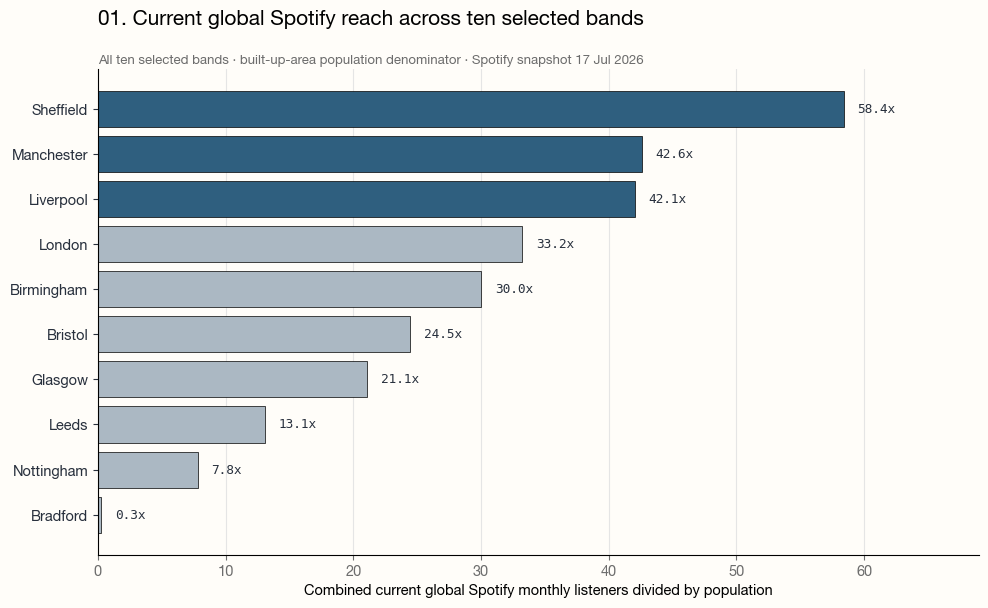

PosixPath('artifacts/charts/chart_01_ten_band_population_normalized_total.png')

In [5]:
figure_01_path = plot_ten_band_population_normalized_total(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=1,
    filename="chart_01_ten_band_population_normalized_total.png",
)
display_path(figure_01_path)


## 05. Why test scene depth?

A city can rank highly because several bands contribute meaningful current
global Spotify reach, or because one act dominates the total. The next chart
shows the largest selected band's share before anything is removed. It
diagnoses concentration but does not alter the primary result.


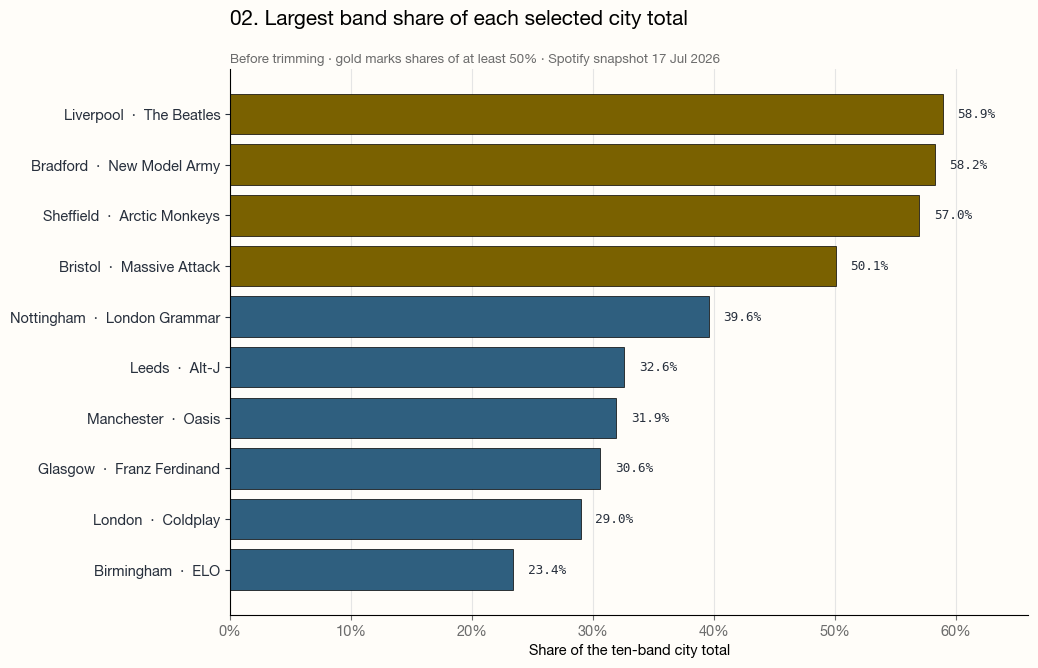

PosixPath('artifacts/charts/chart_02_largest_band_concentration.png')

In [6]:
figure_02_path = plot_top_band_concentration(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=2,
    filename="chart_02_largest_band_concentration.png",
)
display_path(figure_02_path)


The Beatles supply 58.9% of Liverpool's selected total. Arctic Monkeys supply 57.0% of Sheffield's. Manchester is less concentrated: its largest selected band supplies 31.9%.

This motivates the scene-depth test. The question is not whether those bands
“count”; clearly they do in the primary result. The additional test asks
whether the city still looks strong without allowing one current superstar to
determine most of its position.


## 06. Scene-depth test: remove the largest band

After each area's largest selected band is removed,
Manchester, Sheffield and London lead. Manchester moves from rank
2 to 1;
Sheffield moves from 1 to
2 even without Arctic Monkeys; Liverpool moves
from 3 to 5 without
the Beatles.

This is the notebook's only alternative ranking. It retains nine bands per city
and changes only the observation most capable of overwhelming the total.


In [7]:
largest_excluded_table = rankings[
    [
        "top_excluded_rank",
        "city",
        "top_excluded_ratio",
        "highest_excluded_bands",
        "untrimmed_rank",
    ]
].copy()
largest_excluded_table["rank_change"] = (
    largest_excluded_table["untrimmed_rank"]
    - largest_excluded_table["top_excluded_rank"]
)
display(
    largest_excluded_table.sort_values("top_excluded_rank").rename(
        columns={
            "top_excluded_rank": "Rank",
            "city": "City",
            "top_excluded_ratio": "Current global other-nine reach / population",
            "highest_excluded_bands": "Band removed",
            "untrimmed_rank": "All-ten rank",
            "rank_change": "Places gained",
        }
    )
)


,Rank,City,Current global other-nine reach / population,Band removed,All-ten rank,Places gained
0,1,Manchester,29.001188,Oasis,2,1
1,2,Sheffield,25.135618,Arctic Monkeys,1,-1
2,3,London,23.594552,Coldplay,4,1
3,4,Birmingham,22.996840,ELO,5,1
4,5,Liverpool,17.269500,The Beatles,3,-2
5,6,Glasgow,14.632175,Franz Ferdinand,7,1
6,7,Bristol,12.213230,Massive Attack,6,-1
7,8,Leeds,8.849239,Alt-J,8,0
8,9,Nottingham,4.717641,London Grammar,9,0
9,10,Bradford,0.118388,New Model Army,10,0


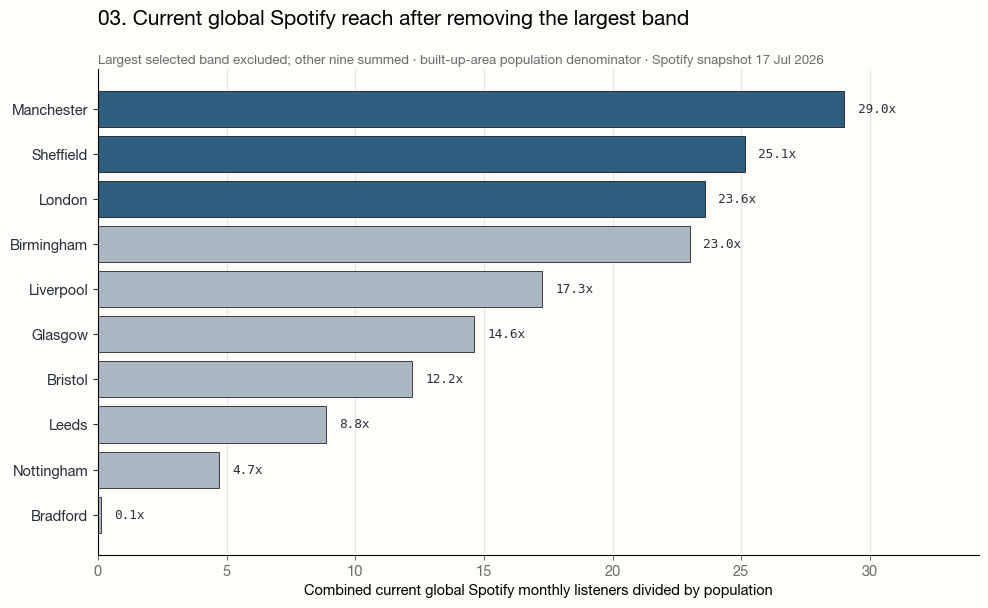

PosixPath('artifacts/charts/chart_03_largest_band_excluded.png')

In [8]:
figure_03_path = plot_top_excluded_population_normalized_total(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=3,
    filename="chart_03_largest_band_excluded.png",
)
display_path(figure_03_path)


## 07. How the ranking changes in the scene-depth test

The final chart compares the primary ranking with the single scene-depth
sensitivity. It is a summary of the rank changes, not another scoring method.


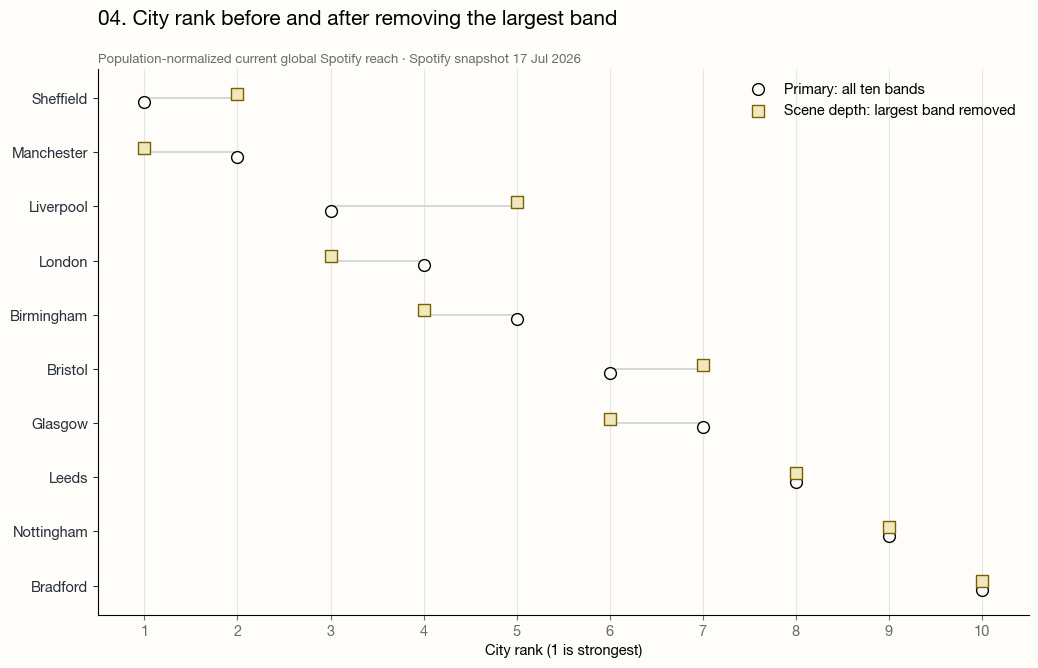

PosixPath('artifacts/charts/chart_04_all_ten_vs_largest_excluded_rank.png')

In [9]:
figure_04_path = plot_primary_vs_top_excluded_rank_comparison(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=4,
    filename="chart_04_all_ten_vs_largest_excluded_rank.png",
)
display_path(figure_04_path)


## 08. Findings

Within this fixed ten-area, 100-band catalogue:

- **Primary all-ten result:** Sheffield, Manchester and Liverpool have the greatest selected
  reach relative to population.
- **Superstar concentration:** the largest band supplies
  58.9% of Liverpool's selected reach,
  57.0% of Sheffield's, and
  31.9% of Manchester's.
- **Largest band excluded:** Manchester ranks
  1, Sheffield
  2, and Liverpool
  5.

The primary and sensitivity results answer different questions. The headline
finding remains the all-ten population-normalized ranking. The scene-depth test
adds that Liverpool's relative position is more dependent on one band, while
Manchester and Sheffield remain strong after their dominant acts are removed.


## 09. Limitations

- The ten built-up areas form a fixed project panel, not a population-selected
  universe of British cities.
- The catalogue is manually curated, excludes solo artists, reflects the
  project's genre lane, and is not a random sample. Largest-band exclusion
  cannot remove this selection bias.
- 6 origin assignments are medium confidence, and
  6 rows remain flagged for editorial review.
- Monthly listeners are volatile global Spotify reach, observed on one
  snapshot date. They do not measure historical impact or local listening.
- Dividing by built-up-area population is a normalization device. It does not
  imply that the listeners live in that area.
- The largest-band test describes sensitivity within ten selected bands. A
  different credible catalogue could produce a different order.

The supported conclusion is deliberately narrow: **the primary result ranks
the full selected catalogue relative to population; the additional
largest-band test shows that Manchester and Sheffield retain comparatively
strong reach beyond their largest act, while Liverpool's rank is more
superstar-dependent.** This is not a definitive ranking of British music
scenes or musical importance.

Charts are saved under `artifacts/charts`.


## Appendix A. Relationship to the earlier five-band publication

The earlier publication is useful as project history, not as part of the main
estimator. It used five bands per area, a follower threshold, and an older data
snapshot. The table below keeps that result visible without asking the reader
to understand it before the current method.


In [10]:
# Keep the original five-band result visible as context, not as a direct equivalent.
FOLLOWER_THRESHOLD = 100_000
PUBLISHED_TOP_N = 3

published_bands = load_shortlist_dataset()
published_eligible = published_bands.loc[
    published_bands["followers"] >= FOLLOWER_THRESHOLD
].copy()
published_rankings = build_city_rankings(
    published_eligible,
    metric="monthly_listeners",
    top_n=PUBLISHED_TOP_N,
)

method_comparison = (
    published_rankings[["city", "rank"]]
    .rename(columns={"rank": "published_five_band_rank"})
    .merge(
        rankings[["city", "untrimmed_rank", "top_excluded_rank"]],
        on="city",
        validate="one_to_one",
    )
    .sort_values("untrimmed_rank")
)
display(
    method_comparison.rename(
        columns={
            "city": "City",
            "published_five_band_rank": "Published five-band rank",
            "untrimmed_rank": "All-ten rank",
            "top_excluded_rank": "Largest-excluded rank",
        }
    )
)


,City,Published five-band rank,All-ten rank,Largest-excluded rank
0,Sheffield,1,1,2
2,Manchester,3,2,1
1,Liverpool,2,3,5
5,London,6,4,3
4,Birmingham,5,5,4
3,Bristol,4,6,7
6,Glasgow,7,7,6
7,Leeds,8,8,8
8,Nottingham,9,9,9
9,Bradford,10,10,10


The five-band and all-ten views happen to identify the same leading cluster:
Sheffield, Liverpool and Manchester. Their ranks should not be interpreted as a clean
before-and-after comparison because the catalogue, eligibility rule, and
snapshot all changed.


## Appendix B. Useful dead ends

These routes shaped the final method, but they are process history rather than
onboarding material.

### Google Trends

Google Trends looked like a common popularity measure, but each request is
sampled and normalized to its own peak. Comparing many bands required batches
and anchor acts; changing the anchors or time window could change the apparent
city totals. The charts were possible, but the cross-band comparison was not
defensible.

### MusicBrainz as an automatic catalogue

MusicBrainz widened the candidate pool and helped resolve identities. It could
not decide the study's editorial questions: what counts as a band, where an act
formed, how ambiguous names should be handled, or where the genre boundary
sits. It became discovery and evidence infrastructure rather than an automatic
sampling frame.

### The first 50-band design

The earlier five-band-per-area version used a follower threshold and an older
Spotify snapshot. The threshold created uneven eligibility, and the saved data
contained one known artist mismatch. Those problems motivated reviewed Spotify
IDs, a balanced ten-band catalogue, no follower threshold, and the explicit
concentration tests used here.

The underlying work remains preserved in the
[Google Trends archive](../archive/google-trends/README.md), the
[original scratchpad](../archive/original-analysis/python_uk_bands.ipynb), and
the [first published notebook](../archive/published-v1/uk_bands_punching_above_weight.ipynb).
